# ΕΠ08 Αναγνώριση Προτύπων – Μηχανική Μάθηση
## 2η Εργασία: Νευρωνικά Δίκτυα για Ταξινόμηση Εικόνων

**Όνομα:** Σκότης Αθανάσιος
**ΑΜ:** 1115202300188

## Αρχικοποίηση & Reproducibility

In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import time
import copy

SEED = 42
# θέτουμε seed παντού για reproducibility
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# χρησιμοποιούμε GPU αν υπάρχει, αλλιώς CPU
print(f'Using device: {DEVICE}')

Using device: cuda


---
# 0. Δεδομένα
## 0.1 Λήψη και Προετοιμασία

In [2]:
# φορτώνουμε εικόνες και ετικέτες από το npz
data = np.load('wikiart_hw2.npz', allow_pickle=True)
X_raw   = data['X']
y_raw   = data['y']
class_names = data['class_names']

print('X shape:', X_raw.shape, '| dtype:', X_raw.dtype)
print('y shape:', y_raw.shape, '| dtype:', y_raw.dtype)
print('Classes:', list(class_names))

X shape: (5400, 32, 32, 3) | dtype: uint8
y shape: (5400,) | dtype: int64
Classes: [np.str_('Baroque'), np.str_('Impressionism'), np.str_('Cubism'), np.str_('Abstract_Expressionism')]


In [3]:
# κανονικοποιούμε pixel
# αλλάζουμε σειρά διαστάσεων: (N,H,W,C) -> (N,C,H,W) όπως θέλει το PyTorch
X_tensor = torch.tensor(X_raw, dtype=torch.float32) / 255.0
X_tensor = X_tensor.permute(0, 3, 1, 2)
y_tensor = torch.tensor(y_raw, dtype=torch.int64)

print('X tensor shape:', X_tensor.shape)
print('y tensor shape:', y_tensor.shape)
print('X min/max:', X_tensor.min().item(), X_tensor.max().item())

X tensor shape: torch.Size([5400, 3, 32, 32])
y tensor shape: torch.Size([5400])
X min/max: 0.0 1.0


In [4]:
# πρώτο split: test vs train+val, stratified για ισορροπία κλάσεων
# Πρώτο split: train+val (4000) vs test (1400)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_tensor, y_tensor,
    test_size=1400, stratify=y_tensor, random_state=42
)

# δεύτερο split: χωρίζουμε train από val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=800, stratify=y_trainval, random_state=42
)

# ελέγχουμε ότι κάθε κλάση έχει σωστή κατανομή
print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
for i, name in enumerate(class_names):
    tr = (y_train == i).sum().item()
    val_acc = (y_val   == i).sum().item()
    te = (y_test  == i).sum().item()
    print(f'  {name}: train={tr}, val={val_acc}, test={te}')

Train: 3200 | Val: 800 | Test: 1400
  Baroque: train=800, val=200, test=350
  Impressionism: train=800, val=200, test=350
  Cubism: train=800, val=200, test=350
  Abstract_Expressionism: train=800, val=200, test=350


In [5]:
# φτιάχνουμε DataLoader για κάθε split με batch_size=16
BATCH = 16

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

# shuffle=True μόνο στο train για τυχαία σειρά σε κάθε εποχή
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print('Train batches:', len(train_loader))
print('Val batches:  ', len(val_loader))
print('Test batches: ', len(test_loader))

Train batches: 200
Val batches:   50
Test batches:  88


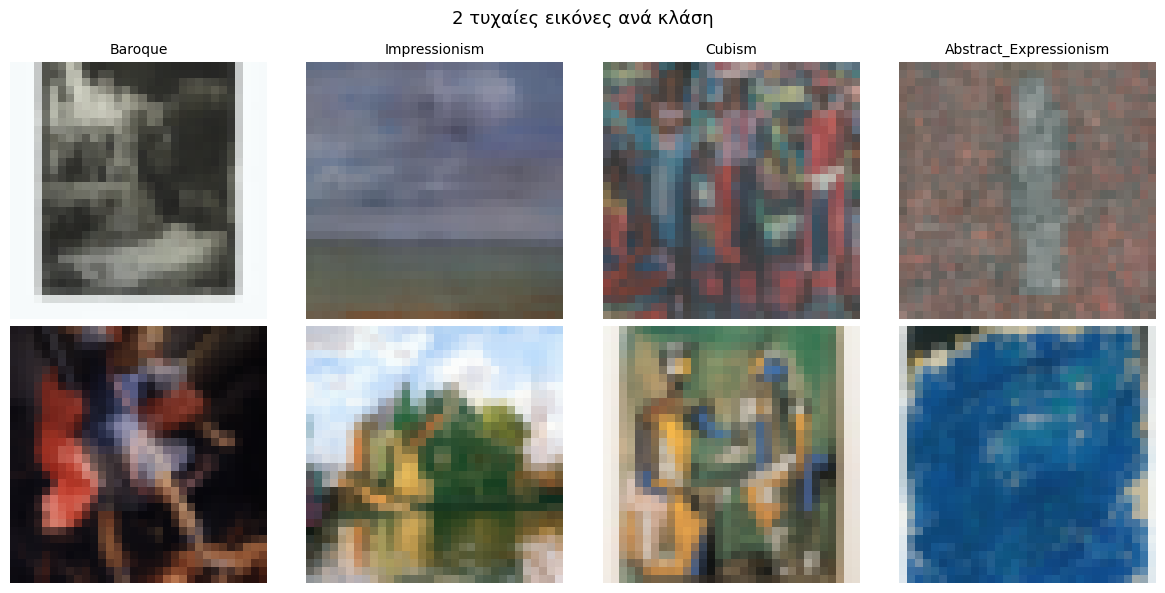

In [6]:
# διαλέγουμε 2 τυχαίες εικόνες ανά κλάση για να δούμε πώς μοιάζουν
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for col, (i, name) in enumerate(zip(range(4), class_names)):
    idx = (y_train == i).nonzero(as_tuple=True)[0]
    chosen = idx[torch.randperm(len(idx), generator=torch.Generator().manual_seed(42))[:2]]
# fixed seed στο Generator για reproducible επιλογή εικόνων
    for row in range(2):
        img = X_train[chosen[row]].permute(1, 2, 0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(name, fontsize=10)
plt.suptitle('2 τυχαίες εικόνες ανά κλάση', fontsize=13)
plt.tight_layout()
plt.show()

## Q0.1
---

Από την οπτικοποίηση 2×4, οι πιο εμφανείς διαφορές μεταξύ των καλλιτεχνικών ρευμάτων είναι τα χρώματα και το αν υπάρχει κάποιο αναγνωρίσιμο θέμα στην εικόνα. Το Baroque έχει συνήθως πιο σκούρα χρώματα και έντονες αντιθέσεις φωτός και σκιάς. Το Impressionism χρησιμοποιεί πιο ανοιχτά και φωτεινά χρώματα και συχνά απεικονίζει τοπία ή σκηνές από τη φύση. Το Cubism ξεχωρίζει από τα γεωμετρικά σχήματα και τις αποδομημένες μορφές, ενώ το Abstract Expressionism είναι πιο αφηρημένο και συνήθως δεν περιέχει κάποιο ξεκάθαρο θέμα.

Το πιο δύσκολο ζεύγος για έναν ταξινομητή πιθανότατα είναι το Cubism και το Abstract Expressionism, επειδή και τα δύο περιέχουν αφηρημένα στοιχεία και σε ορισμένες εικόνες δεν είναι εύκολο να ξεχωρίσει κανείς το θέμα. Επίσης, το Baroque και το Impressionism μπορεί να μπερδευτούν μεταξύ τους, καθώς και τα δύο έχουν αναγνωρίσιμες σκηνές και η χαμηλή ανάλυση των 32×32 pixels κρύβει αρκετές λεπτομέρειες που βοηθούν στη διάκρισή τους.

Για έναν άνθρωπο, το πιο δύσκολο κίνημα να αναγνωριστεί σε ανάλυση 32×32 είναι πιθανότατα το Abstract Expressionism, επειδή πολλές εικόνες του δεν έχουν ξεκάθαρα αντικείμενα ή μορφές και έτσι μπορούν εύκολα να συγχυθούν με εικόνες από άλλα καλλιτεχνικά ρεύματα.

---
# 1. Feedforward Neural Network σε raw pixels
## 1.1 Αρχιτεκτονική και εκπαίδευση

In [7]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3072, 128)
        self.fc2 = nn.Linear(128, 32)
        self.fc3 = nn.Linear(32, 4)

        self.relu = nn.ReLU()
# δοκιμάζουμε με dummy input για να επαληθεύσουμε το output shape

    def forward(self, x: torch.Tensor):
        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

# Test
model = FFN()
dummy = torch.randn(4, 3, 32, 32)
print('FFN output shape:', model(dummy).shape)
print('FFN total params:', sum(p.numel() for p in model.parameters()))

FFN output shape: torch.Size([4, 4])
FFN total params: 397604


In [8]:
# training με back propagation

def train_one_epoch(model, loader, optimizer, loss_func, device):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x)
        loss = loss_func(logits, y)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

# τρέχει σε eval mode χωρίς gradients
def evaluate(model, loader, loss_func, device):
    model.eval()
    total_loss = 0.0
# μαζεύουμε predictions και labels για f1 και confusion matrix
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_func(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    cm  = confusion_matrix(all_labels, all_preds)

    return avg_loss, acc, f1, cm


In [9]:
# Γενική συνάρτηση εκπαίδευσης
# κρατάμε το best model state με βάση val F1
def train_model(model, train_loader, val_loader, optimizer, loss_func,
                n_epochs, device, scheduler=None, desc=''):

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_f1, best_epoch, best_state = 0.0, 0, None

    model.to(device)
    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_func, device)
        val_loss, val_acc, val_f1, _ = evaluate(model, val_loader, loss_func, device)
        if scheduler: scheduler.step()
# αν δοθεί scheduler, κάνουμε step μετά από κάθε εποχή

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_f1 > best_f1:
            best_f1  = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
# τυπώνουμε stats κάθε 5 εποχές για να παρακολουθούμε την πρόοδο

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{desc}] Epoch {epoch:3d}/{n_epochs} | '
                  f'train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
                  f'val_acc={val_acc:.4f} | val_f1={val_f1:.4f}')

    print(f'  → Best epoch: {best_epoch} (val F1={best_f1:.4f})')
    return history, best_state, best_epoch

In [10]:
# εκπαίδευση FFN σε CPU για σύγκριση χρόνου
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
# επαναρχικοποιούμε seeds πριν κάθε run για fair σύγκριση
torch.cuda.manual_seed_all(SEED)
ffn_cpu = FFN()
opt_cpu = optim.Adam(ffn_cpu.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()

t0 = time.time()
hist_ffn_cpu, best_ffn_cpu_state, best_ffn_cpu_ep = train_model(
    ffn_cpu, train_loader, val_loader, opt_cpu, loss_func, 30, torch.device('cpu'), desc='FFN-CPU')
cpu_time = time.time() - t0
print(f'FFN CPU training time: {cpu_time:.1f}s')

[FFN-CPU] Epoch   1/30 | train_loss=1.3785 | val_loss=1.3477 | val_acc=0.3412 | val_f1=0.2504
[FFN-CPU] Epoch   5/30 | train_loss=1.2400 | val_loss=1.2494 | val_acc=0.4200 | val_f1=0.3496
[FFN-CPU] Epoch  10/30 | train_loss=1.1639 | val_loss=1.1962 | val_acc=0.4550 | val_f1=0.4322
[FFN-CPU] Epoch  15/30 | train_loss=1.0730 | val_loss=1.2162 | val_acc=0.4500 | val_f1=0.4413
[FFN-CPU] Epoch  20/30 | train_loss=1.0287 | val_loss=1.1914 | val_acc=0.4713 | val_f1=0.4734
[FFN-CPU] Epoch  25/30 | train_loss=0.9651 | val_loss=1.1897 | val_acc=0.4900 | val_f1=0.4919
[FFN-CPU] Epoch  30/30 | train_loss=0.9198 | val_loss=1.2141 | val_acc=0.4838 | val_f1=0.4743
  → Best epoch: 25 (val F1=0.4919)
FFN CPU training time: 48.6s


In [11]:
# εκπαίδευση FFN σε GPU
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
ffn_gpu = FFN()
opt_gpu = optim.Adam(ffn_gpu.parameters(), lr=0.001)

# ο λόγος cpu_time/gpu_time μας δίνει το speedup
t0 = time.time()
hist_ffn_gpu, best_ffn_state, best_ffn_ep = train_model(
    ffn_gpu, train_loader, val_loader, opt_gpu, loss_func, 30, DEVICE, desc='FFN-GPU')
gpu_time_ffn = time.time() - t0

print(f'FFN GPU training time: {gpu_time_ffn:.1f}s')
print(f'Speedup CPU/GPU: {cpu_time/gpu_time_ffn:.2f}x')

[FFN-GPU] Epoch   1/30 | train_loss=1.3785 | val_loss=1.3477 | val_acc=0.3412 | val_f1=0.2504
[FFN-GPU] Epoch   5/30 | train_loss=1.2400 | val_loss=1.2494 | val_acc=0.4200 | val_f1=0.3496
[FFN-GPU] Epoch  10/30 | train_loss=1.1639 | val_loss=1.1962 | val_acc=0.4550 | val_f1=0.4322
[FFN-GPU] Epoch  15/30 | train_loss=1.0730 | val_loss=1.2162 | val_acc=0.4500 | val_f1=0.4413
[FFN-GPU] Epoch  20/30 | train_loss=1.0287 | val_loss=1.1914 | val_acc=0.4713 | val_f1=0.4734
[FFN-GPU] Epoch  25/30 | train_loss=0.9651 | val_loss=1.1897 | val_acc=0.4900 | val_f1=0.4919
[FFN-GPU] Epoch  30/30 | train_loss=0.9198 | val_loss=1.2141 | val_acc=0.4838 | val_f1=0.4743
  → Best epoch: 25 (val F1=0.4919)
FFN GPU training time: 14.4s
Speedup CPU/GPU: 3.38x


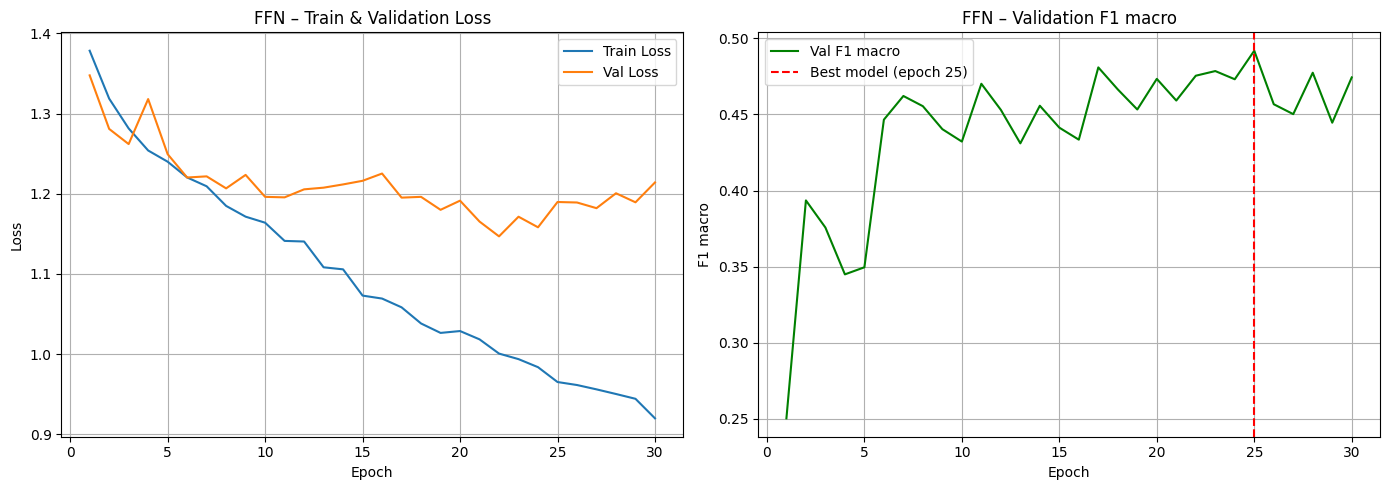

In [12]:
# Διαγράμματα loss και val F1
epochs = range(1, 31)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (α) Train & Val Loss
ax1.plot(epochs, hist_ffn_gpu['train_loss'], label='Train Loss')
ax1.plot(epochs, hist_ffn_gpu['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('FFN – Train & Validation Loss')
ax1.legend(); ax1.grid(True)

# (β) Val F1 + best epoch
ax2.plot(epochs, hist_ffn_gpu['val_f1'], label='Val F1 macro', color='green')
# κόκκινη γραμμή στην εποχή με το καλύτερο val F1
ax2.axvline(x=best_ffn_ep, color='red', linestyle='--',
            label=f'Best model (epoch {best_ffn_ep})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 macro')
ax2.set_title('FFN – Validation F1 macro')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## Q1.1
---

Από τα loss curves, παρατηρείται overfitting: το train loss μειώνεται σταθερά (1.38 -> 0.93), ενώ το validation loss σταθεροποιείται περίπου στην εποχή 15 (val_loss=1.18) και στη συνέχεια παραμένει στάσιμο ή ανεβαίνει ελαφρά (π.χ. epoch 30: train=0.93, val=1.18). Αντίστοιχα, το val F1 macro κορυφώνεται και σταθεροποιείται ενώ το train loss συνεχίζει να πέφτει.

Το best model επιλέχθηκε στην εποχή 25 (val F1=0.49 για CPU / 0.49 για GPU). Αν χρησιμοποιούσαμε το train loss ως κριτήριο, θα επιλεγόταν η εποχή 30, η οποία όμως αντιστοιχεί σε υψηλότερο val loss και πιο overfitted μοντέλο.Η επιλογή με βάση το validation set είναι κρίσιμη γιατί εγγυάται ότι κρατάμε το μοντέλο με την καλύτερη γενίκευση σε δεδομένα που δεν έχει εκπαιδευτεί το μοντέλο, και όχι απλώς το πιο overfitted στο train set.

Το GPU speedup (3.42x) ήταν αναμενόμενα μέτριο για ένα δίκτυο αυτού του μεγέθους (397.000 παράμετροι, μικρά batches 16 εικόνων 32*32).

In [13]:
# φορτώνουμε το best model και αξιολογούμε στο test set
ffn_gpu.load_state_dict(best_ffn_state)
_, test_acc_ffn, test_f1_ffn, test_cm_ffn = evaluate(ffn_gpu, test_loader, loss_func, DEVICE)
print(f'FFN Test Accuracy: {test_acc_ffn:.4f}')
print(f'FFN Test F1 macro: {test_f1_ffn:.4f}')
print('Confusion Matrix:')
print(test_cm_ffn)

FFN Test Accuracy: 0.4979
FFN Test F1 macro: 0.5014
Confusion Matrix:
[[182  23  72  73]
 [ 33 138 105  74]
 [ 25  35 160 130]
 [ 23  26  84 217]]


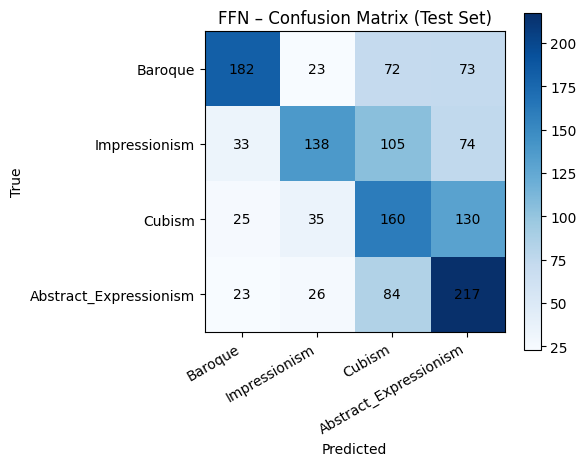

In [14]:
# Q1.2 – Confusion matrix οπτικοποίηση
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(test_cm_ffn, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('FFN – Confusion Matrix (Test Set)')
# γράφουμε τον αριθμό δειγμάτων σε κάθε κελί
for i in range(4):
    for j in range(4):
        ax.text(j, i, test_cm_ffn[i, j], ha='center', va='center', color='black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

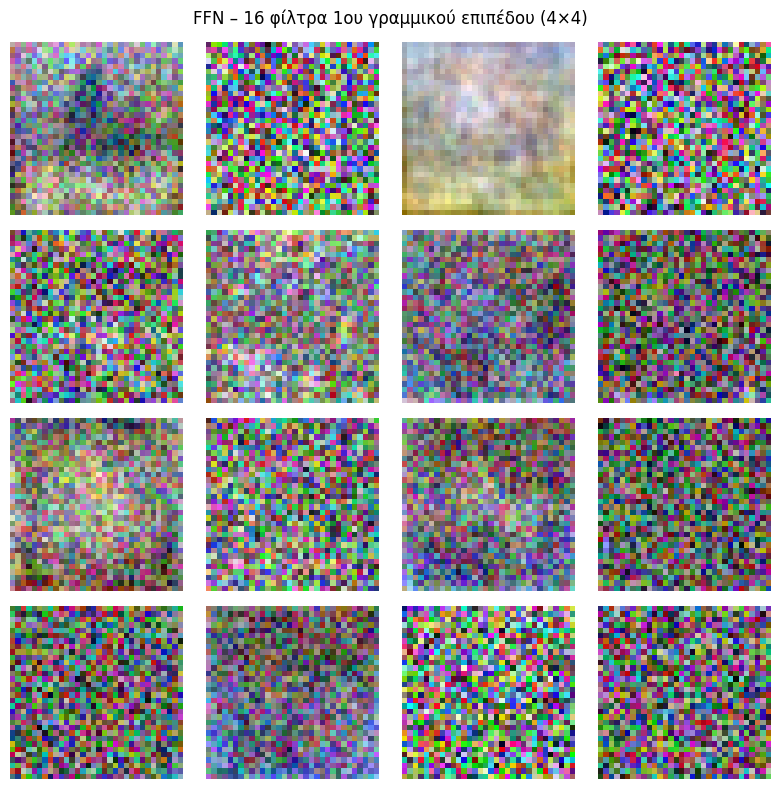

In [15]:
# -- Q1.2 – Οπτικοποίηση βαρών 1ου γραμμικού επιπέδου
# βάρη fc1: shape [128, 3072], τα κάνουμε reshape σε [128,3,32,32] για να δούμε την εικόνα κάθε νευρώνα
w1 = ffn_gpu.fc1.weight.data.cpu()
w1_img = w1.reshape(128, 3, 32, 32)
# κανονικοποιούμε κάθε φίλτρο ξεχωριστά στο [0,1] για εμφάνιση

# Min-max κανονικοποίηση ανά φίλτρο για να διατηρήσουμε το σχήμα της κατανομής ακριβώς
w1_norm = w1_img.clone()
for f in range(128):
    mn, mx = w1_img[f].min(), w1_img[f].max()
    w1_norm[f] = (w1_img[f] - mn) / (mx - mn + 1e-8)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(w1_norm[i].permute(1, 2, 0).numpy())
    ax.axis('off')
plt.suptitle('FFN – 16 φίλτρα 1ου γραμμικού επιπέδου (4×4)', fontsize=12)
plt.tight_layout()
plt.show()

## Q1.2
---

Τα κινήματα που μπερδεύονται περισσότερο είναι Cubism–Abstract Expressionism (130 Cubism προβλέφθηκε ως Abstract, 84 Abstract ως Cubism) και Impressionism–Cubism (105 Impressionism προβλέφθηκε ως Cubism). Το Abstract Expressionism ταξινομείται καλύτερα (217/350 σωστά), λόγω του ότι το μοντέλο φαίνεται να μαντεύει περισσότερο αυτό και μετά το Cubism στις προβλέψεις του σε μεγάλο βαθμό.
Κάθε νευρώνας του πρώτου γραμμικού επιπέδου υπολογίζει ένα weighted sum όλων των pixel ταυτόχρονα, δηλαδή βλέπει μόνο global μοτίβα χρώματος σε επίπεδο ολόκληρης εικόνας. Τα 16 φίλτρα εμφανίζονται θορυβώδη ή διάχυτα (ομοιόμορφα χρωματικά πεδία) χωρίς καθαρές χωρικές δομές γενικά (πέρα από το 1ο λίγο) κρατώντας μόνο τη σκουρότητα του χρώματος λίγο και στο 3ο φίλτρο φαίνονται τα μοτίβα χρώματος του Impressionism. Αυτό είναι πολύ κακό γιατί έχει μπερδέψει τα κινήματα λόγο των δύσκολων χαρακτηριστικών των Cubism και Abstract Expressionism και μπερδεύει τους περισσότερους ότι είναι αυτών των 2 κινημάτων.

Αυτή η αρχιτεκτονική αδυνατεί να εκμεταλλευτεί τοπικά χωρικά patterns (ακμές, υφές, συνθέσεις σε μικρές περιοχές) που είναι ακριβώς αυτά που διαφοροποιούν τα καλλιτεχνικά κινήματα — π.χ. τις πινελιές του Impressionism ή τη γεωμετρική θραυσματοποίηση του Cubism. Το Flatten καταστρέφει κάθε χωρική πληροφορία γειτνίασης pixel.


---
# 2. Convolutional Neural Network
## 2.1 Σταδιακή κατασκευή

In [16]:
class CNN(nn.Module):
# flags ώστε να δοκιμάζουμε διαφορετικές εκδόσεις του CNN
    def __init__(self, padding=False, pooling=False, activation=False):
        super().__init__()

        pad = 2 if padding else 0
        self.pooling = pooling
        self.activation = activation

        self.conv1 = nn.Conv2d(3,   16, kernel_size=5, padding=pad)
        self.conv2 = nn.Conv2d(16,  32, kernel_size=5, padding=pad)
        self.conv3 = nn.Conv2d(32,  64, kernel_size=5, padding=pad)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=5, padding=pad)

# dummy forward pass για να υπολογίσουμε αυτόματα το flat_size
        self.pool = nn.MaxPool2d(2) if pooling else nn.Identity()
        self.act  = nn.ReLU()       if activation else nn.Identity()

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32)
            dummy = self._forward_conv(dummy)
            flat_size = dummy.view(1, -1).shape[1]
        self.flat_size = flat_size

        self.fc1 = nn.Linear(flat_size, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, 32)
        self.fc4 = nn.Linear(32, 4)

    def _forward_conv(self, x):
        for conv in [self.conv1, self.conv2, self.conv3, self.conv4]:
            x = self.act(conv(x))
            x = self.pool(x)
        return x

    def forward(self, x):
        x = self._forward_conv(x)
        x = x.flatten(1)
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.fc4(x)
        return x


for name, flags in [('2.1 baseline', (False, False, False)),
                    ('2.2 pad+pool', (True,  True,  False)),
                    ('2.3 +ReLU',    (True,  True,  True ))]:
    m = CNN(*flags)
    out = m(torch.randn(2, 3, 32, 32))
    params = sum(p.numel() for p in m.parameters())
    print(f'{name}: flat_size={m.flat_size}, output={out.shape}, params={params:,}')

2.1 baseline: flat_size=32768, output=torch.Size([2, 4]), params=34,096,452
2.2 pad+pool: flat_size=512, output=torch.Size([2, 4]), params=1,066,308
2.3 +ReLU: flat_size=512, output=torch.Size([2, 4]), params=1,066,308


In [17]:
# Εκπαίδευση 2.1, 2.2, 2.3
results_cnn = {}

for version, flags, desc in [
    ('2.1', (False, False, False), '2.1 baseline'),
    ('2.2', (True,  True,  False), '2.2 pad+pool'),
    ('2.3', (True,  True,  True ), '2.3 +ReLU')]:

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    model = CNN(*flags)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

# αξιολογούμε κάθε μοντέλο και στο val και στο test set
    t0 = time.time()
    hist, best_state, best_ep = train_model(
        model, train_loader, val_loader, optimizer, loss_func, 30, DEVICE, desc=desc)
    gpu_time_cnn = time.time() - t0

    model.load_state_dict(best_state)
    _, val_acc, val_f1, _ = evaluate(model, val_loader,  loss_func, DEVICE)
    _, test_acc, test_f1, cm = evaluate(model, test_loader, loss_func, DEVICE)
    params = sum(p.numel() for p in model.parameters())
    results_cnn[version] = {'model': model, 'hist': hist, 'best_ep': best_ep,
                            'val_acc': val_acc, 'val_f1': val_f1,
                            'test_acc': test_acc, 'test_f1': test_f1,
                            'params': params, 'cm': cm,
                            'best_state': best_state, 'gpu_time': gpu_time_cnn}
    print(f'  {desc}: params={params:,} | val_acc={val_acc:.4f} | test_acc={test_acc:.4f} | test_f1={test_f1:.4f}\n')

[2.1 baseline] Epoch   1/30 | train_loss=1.7707 | val_loss=1.3377 | val_acc=0.3538 | val_f1=0.3409
[2.1 baseline] Epoch   5/30 | train_loss=1.2951 | val_loss=1.4106 | val_acc=0.3713 | val_f1=0.3671
[2.1 baseline] Epoch  10/30 | train_loss=1.2649 | val_loss=1.3765 | val_acc=0.3362 | val_f1=0.3377
[2.1 baseline] Epoch  15/30 | train_loss=1.2132 | val_loss=1.3889 | val_acc=0.3125 | val_f1=0.3119
[2.1 baseline] Epoch  20/30 | train_loss=1.1487 | val_loss=1.4938 | val_acc=0.3650 | val_f1=0.3616
[2.1 baseline] Epoch  25/30 | train_loss=1.0956 | val_loss=1.6632 | val_acc=0.3350 | val_f1=0.3312
[2.1 baseline] Epoch  30/30 | train_loss=1.0325 | val_loss=1.7385 | val_acc=0.3350 | val_f1=0.3236
  → Best epoch: 4 (val F1=0.3857)
  2.1 baseline: params=34,096,452 | val_acc=0.4100 | test_acc=0.4200 | test_f1=0.4044

[2.2 pad+pool] Epoch   1/30 | train_loss=1.3583 | val_loss=1.2749 | val_acc=0.4125 | val_f1=0.3789
[2.2 pad+pool] Epoch   5/30 | train_loss=0.8842 | val_loss=1.0091 | val_acc=0.5887 | va

In [18]:
# εκπαίδευση CNN 2.3 σε CPU για να μετρήσουμε το speedup
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
cnn_cpu_model = CNN(True, True, True)
opt_cnn_cpu   = optim.Adam(cnn_cpu_model.parameters(), lr=0.001)
t0 = time.time()
# CNN έχει μεγαλύτερο speedup από FFN λόγω παραλληλισμού των convolutions
hist_cnn_cpu, _, _ = train_model(
    cnn_cpu_model, train_loader, val_loader, opt_cnn_cpu, loss_func, 30,
    torch.device('cpu'), desc='CNN2.3-CPU')
cnn_cpu_time = time.time() - t0

cnn_gpu_time = results_cnn['2.3']['gpu_time']
print(f'CNN 2.3 CPU time:    {cnn_cpu_time:.1f}s')
print(f'CNN 2.3 GPU time:    {cnn_gpu_time:.1f}s')
print(f'CNN CPU/GPU speedup: {cnn_cpu_time / cnn_gpu_time:.2f}x')

[CNN2.3-CPU] Epoch   1/30 | train_loss=1.3309 | val_loss=1.2891 | val_acc=0.3688 | val_f1=0.2906
[CNN2.3-CPU] Epoch   5/30 | train_loss=1.1208 | val_loss=1.1871 | val_acc=0.4250 | val_f1=0.4078
[CNN2.3-CPU] Epoch  10/30 | train_loss=0.9069 | val_loss=1.0121 | val_acc=0.5950 | val_f1=0.5949
[CNN2.3-CPU] Epoch  15/30 | train_loss=0.6352 | val_loss=0.9690 | val_acc=0.6200 | val_f1=0.6161
[CNN2.3-CPU] Epoch  20/30 | train_loss=0.3209 | val_loss=1.3310 | val_acc=0.6038 | val_f1=0.6093
[CNN2.3-CPU] Epoch  25/30 | train_loss=0.2102 | val_loss=1.6261 | val_acc=0.6062 | val_f1=0.5984
[CNN2.3-CPU] Epoch  30/30 | train_loss=0.1276 | val_loss=1.9890 | val_acc=0.6150 | val_f1=0.6154
  → Best epoch: 19 (val F1=0.6439)
CNN 2.3 CPU time:    230.6s
CNN 2.3 GPU time:    24.9s
CNN CPU/GPU speedup: 9.25x


## Q2.1
---

| Έκδοση | # params | Val Acc | Test Acc | F1 macro |
|--------|----------|---------|----------|----------|
| 2.1   | 34,096,452 | 0.4100 | 0.4200   | 0.4044   |
| 2.2   | 1,066,308  | 0.6150 | 0.5936   | 0.5927   |
| 2.3   | 1,066,308  | 0.6162 | 0.5900   | 0.5817   |

Η αλλαγή που επηρέασε περισσότερο τον αριθμό παραμέτρων ήταν η προσθήκη padding και pooling (2.1 → 2.2). Οι παράμετροι μειώθηκαν από 34 εκατομμύρια σε 1 εκατομμύριο, γιατί το MaxPool2d μειώνει το μέγεθος των feature maps μετά από κάθε convolution περισσότερο από ότι προστίθεται με το padding. Έτσι, το flatten δίνει  πολύ μικρότερο διάνυσμα (512 αντί για 32.768), οπότε και το fully connected layer έχει πολύ λιγότερες παραμέτρους.

Η αλλαγή που επηρέασε περισσότερο την απόδοση ήταν επίσης η μετάβαση από 2.1 σε 2.2 (F1 από 0.41 σε 0.60). Στην 2.1, επειδή δεν υπάρχει padding, τα output του conolution layer μικραίνουν γρήγορα και χάνεται πληροφορία όσο προχωράμε layers.

Επίσης, ένα βασικό πρόβλημα της 2.1 είναι ότι δεν υπάρχουν activations. Αυτό σημαίνει ότι τα convolutional layers είναι απλά γραμμικοί μετασχηματισμοί. Άρα πολλά συνεχόμενα linear layers μπορούν να συμπτυχθούν σε ένα μόνο linear layer. Στην πράξη αυτό κάνει το δίκτυο να έχει πολύ μικρότερη εκφραστικότητα από αυτή που θέλουμε.

Για αυτό, παρότι η 2.1 έχει πάρα πολλές παραμέτρους (34M), δεν χρησιμοποιεί σωστά την πληροφορία της(δεν μαθαίνει + συμπιέζει σωστά τα χαρακτηριστικά της εικόνας της για τα fc layers) και αδυνατεί να την εκφράσει(χάνεται το βάθος στα fc layers λόγω έλειψης μη γραμμικής σχέσης), με αποτέλεσμα να μην αποδίδει καλά (F1 = 0.41).

Το 2.3 φαίνεται να κάνει overfit λόγω της μη γραμμικότητας που βάζει και αλλό βάθος στο δίκτυο χωρίς regularization.

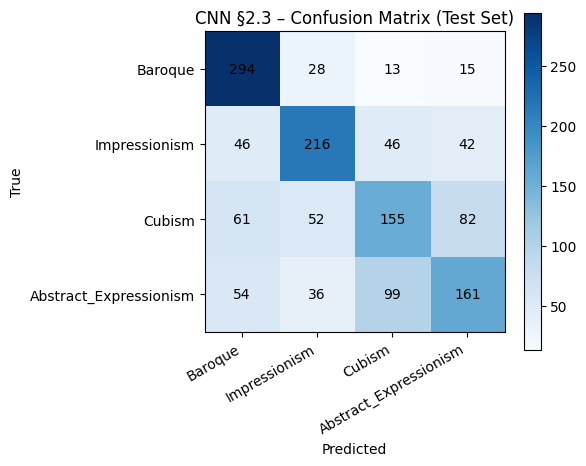

In [19]:
# Q2.2 – Confusion matrix CNN 2.3
test_cm_cnn = results_cnn['2.3']['cm']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(test_cm_cnn, cmap='Blues')
# βλέπουμε ποιες κλάσεις μπερδεύονται μεταξύ τους
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('CNN §2.3 – Confusion Matrix (Test Set)')
for i in range(4):
    for j in range(4):
        ax.text(j, i, test_cm_cnn[i, j], ha='center', va='center', color='black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Q2.2
---

Το CNN §2.3 έχει **1.066.308 παραμέτρους** έναντι **397.604 του FFN** (~2.7× περισσότερες), και επιτυγχάνει **test F1 macro = 0.5718** έναντι **0.5014 του FFN** (+7 ποσοστιαίες μονάδες). Ο αριθμός παραμέτρων από μόνος του δεν προβλέπει επίδοση, αυτό που κάνει τη διαφορά είναι η δομή τους και η prior knowledge που κωδικοποιούν. Τα συνελικτικά φίλτρα επιβάλλουν τοπική συνεκτικότητα (κάθε νευρώνας βλέπει μια μικρή περιοχή 5×5) και τα κοινά weights (ίδιο φίλτρο σε όλες τις θέσεις), εκμεταλλευόμενα το γεγονός ότι τα οπτικά χαρακτηριστικά είναι τοπικά και το invariance που προκύπτει. Το FFN αντίθετα βλέπει κάθε pixel ανεξάρτητα, χωρίς καμία πληροφορία γειτνίασης, και αδυνατεί να εντοπίσει υφές, ακμές ή χρωματικές μεταβάσεις σε τοπικό επίπεδο.

Στα confusion matrices, το CNN βελτιώνεται δραματικά στο **Baroque** (+112 σωστές ταξινομήσεις, από 182 σε 294) και στο **Impressionism** (+78, από 138 σε 216), κινήματα που χαρακτηρίζονται από συγκεκριμένες τοπικές υφές και χρωματικές δομές (έντονες αντιθέσεις φως-σκιάς για Baroque, χαρακτηριστικές πινελιές και γεωμετρίες για Impressionism) που τα φίλτρα συνέλιξης αναγνωρίζουν αποτελεσματικά. Αντίθετα, το **Abstract Expressionism** χειροτερεύει (−56, από 217 σε 161), πιθανώς γιατί η απουσία επαναλαμβανόμενων τοπικών δομών στα αφηρημένα έργα δυσκολεύει τα φίλτρα, ενώ το FFN ευνοούσε τυχαία αυτή την κλάση μέσω global χρωματικών στατιστικών. Το CPU/GPU speedup του CNN είναι μεγαλύτερο από αυτό του FFN (3.42×), επειδή τα CNN εκτελούν πολύ περισσότερους υπολογισμούς που μπορούν να γίνουν ταυτόχρονα. Στα CNN ο ίδιος kernel γίνεται shift πάνω στην εικόνα δημιουργόντας πάρα πολλές παράλληλες εξόδους, ενώ με το FFN οι παράλληλοι έξοδοι είναι περιορισμενοι και οι υπολογισμοί για την κάθε μία περισσότεροι.

## Q2.3
---

Από τα αποτελέσματα του notebook, το CNN §2.3 με 4 conv layers έχει ήδη σοβαρό overfitting: το train loss πέφτει στο 0.11 ενώ το val loss ανεβαίνει στο 2.5, που σημαίνει ότι το δίκτυο απομνημονεύει το training set αντί να μαθαίνει γενικά χαρακτηριστικά. Το πρόβλημα δηλαδή δεν είναι ότι το δίκτυο είναι μικρό, είναι ότι έχουμε πολύ λίγα δεδομένα (3.200 εικόνες train) για την πολυπλοκότητα που ήδη έχουμε. Άρα το να προσθέσουμε άλλα 6 conv layers θα έκανε το overfitting ακόμα χειρότερο, και το +2% που περιμένουμε πιθανώς δεν θα εμφανιστεί ποτέ στην πράξη.

Η επιλογή έχει νόημα μόνο αν το μουσείο έχει αρκετά labeled έργα για να εκπαιδεύσει ένα τόσο βαθύ δίκτυο σωστά, και αν η ταξινόμηση γίνεται μία φορά (π.χ. όταν συλλεχθούν όλα τα έργα του μουσείου) και όχι σε real time, γιατί δεν μας νοιάζει τόσο πολύ ο χρόνος, κρύβεται περίπου γιατί γίνεται μία φορά, έτσι προτιμάται το βαθύτερο δίκτυο και ας είναι πολύ πιο αργό. Επίσης, το κόστος ρεύματος για να τρέξεις ένα τόσο βαρύ μοντέλο σε 2.000.000 εικόνες είναι σημαντικό, και ένα μουσείο συνήθως δεν έχει τον αντίστοιχο budget. Τέλος, οι επιμελητές του μουσείου μπορεί να χρειάζεται να καταλαβαίνουν γιατί ένα έργο πήγε σε μια κατηγορία, ένα βαθύτερο δίκτυο είναι ακόμα πιο δύσκολο να ερμηνευτεί από αυτό που ήδη έχουμε καθώς όσα περισσότερα επίπεδα έχουμε τόσο λιγότερο μπορούμε να καταλάβουμε τι οδηγεί στο αποτέλεσμα από τα βάρη και τι κάνει το κάθε επίπεδο.

---
# 3. Βελτίωση Επίδοσης
## 3.1 Reproducibility, Optimizers, LR Schedule, BatchNorm

In [20]:
# τρέχουμε δύο φορές ακριβώς το ίδιο training για να ελέγξουμε reproducibility
def full_reproducibility_run():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    m = CNN(True, True, True)
    opt = optim.Adam(m.parameters(), lr=0.001)
    hist, best_state, _ = train_model(
        m, train_loader, val_loader, opt, loss_func, 30, DEVICE, desc='repro')
    m.load_state_dict(best_state)
    _, test_acc, test_f1, _ = evaluate(m, test_loader, loss_func, DEVICE)
    return hist['train_loss'], test_acc, test_f1

losses1, acc1, f1_1 = full_reproducibility_run()
losses2, acc2, f1_2 = full_reproducibility_run()

losses_identical = np.allclose(losses1, losses2, atol=1e-6)
print('Train losses identical:', losses_identical)
print(f'Test Acc: run1={acc1:.4f}, run2={acc2:.4f} | identical: {acc1==acc2}')
print(f'Test F1:  run1={f1_1:.4f}, run2={f1_2:.4f} | identical: {f1_1==f1_2}')

[repro] Epoch   1/30 | train_loss=1.3248 | val_loss=1.2844 | val_acc=0.3463 | val_f1=0.2522
[repro] Epoch   5/30 | train_loss=1.1493 | val_loss=1.1588 | val_acc=0.4863 | val_f1=0.4445
[repro] Epoch  10/30 | train_loss=0.9001 | val_loss=1.0293 | val_acc=0.5450 | val_f1=0.5318
[repro] Epoch  15/30 | train_loss=0.5965 | val_loss=1.0764 | val_acc=0.5913 | val_f1=0.5861
[repro] Epoch  20/30 | train_loss=0.2651 | val_loss=1.9074 | val_acc=0.5750 | val_f1=0.5790
[repro] Epoch  25/30 | train_loss=0.1680 | val_loss=1.8888 | val_acc=0.5863 | val_f1=0.5849
[repro] Epoch  30/30 | train_loss=0.1640 | val_loss=2.2640 | val_acc=0.5875 | val_f1=0.5915
  → Best epoch: 17 (val F1=0.6120)
[repro] Epoch   1/30 | train_loss=1.3248 | val_loss=1.2844 | val_acc=0.3463 | val_f1=0.2522
[repro] Epoch   5/30 | train_loss=1.1493 | val_loss=1.1588 | val_acc=0.4863 | val_f1=0.4445
[repro] Epoch  10/30 | train_loss=0.9001 | val_loss=1.0293 | val_acc=0.5450 | val_f1=0.5318
[repro] Epoch  15/30 | train_loss=0.5965 | va

In [21]:
# δοκιμάζουμε 5 optimizers με την ίδια αρχιτεκτονική (CNN 2.3)
optimizers_cfg = {
    'SGD':          lambda p: optim.SGD(p, lr=0.01),
    'SGD+momentum': lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
    'Adam':         lambda p: optim.Adam(p, lr=0.001),
    'RMSprop':      lambda p: optim.RMSprop(p, lr=0.001),
    'AdamW':        lambda p: optim.AdamW(p, lr=0.001, weight_decay=0.01),
}

# επαναρχικοποιούμε seeds πριν από κάθε optimizer για fair σύγκριση
opt_results = {}
for opt_name, opt_fn in optimizers_cfg.items():
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = CNN(True, True, True)
    optimizer = opt_fn(model.parameters())

    hist, best_state, best_ep = train_model(
        model, train_loader, val_loader, optimizer, loss_func, 30, DEVICE, desc=opt_name)

    model.load_state_dict(best_state)
    _, val_acc, val_f1, _ = evaluate(model, val_loader,  loss_func, DEVICE)
    _, test_acc, test_f1, _ = evaluate(model, test_loader, loss_func, DEVICE)

    opt_results[opt_name] = {'val_acc': val_acc, 'test_acc': test_acc, 'f1': test_f1, 'best_ep': best_ep, 'hist': hist}
    print(f'{opt_name}: val_acc={val_acc:.4f} | test_acc={test_acc:.4f} | f1={test_f1:.4f} | best_ep={best_ep}\n')

[SGD] Epoch   1/30 | train_loss=1.3904 | val_loss=1.3884 | val_acc=0.2500 | val_f1=0.1000
[SGD] Epoch   5/30 | train_loss=1.3866 | val_loss=1.3863 | val_acc=0.2500 | val_f1=0.1000
[SGD] Epoch  10/30 | train_loss=1.3865 | val_loss=1.3862 | val_acc=0.2500 | val_f1=0.1000
[SGD] Epoch  15/30 | train_loss=1.3864 | val_loss=1.3862 | val_acc=0.2500 | val_f1=0.1000
[SGD] Epoch  20/30 | train_loss=1.3863 | val_loss=1.3861 | val_acc=0.2500 | val_f1=0.1000
[SGD] Epoch  25/30 | train_loss=1.3861 | val_loss=1.3858 | val_acc=0.3387 | val_f1=0.2325
[SGD] Epoch  30/30 | train_loss=1.3855 | val_loss=1.3854 | val_acc=0.2500 | val_f1=0.1355
  → Best epoch: 28 (val F1=0.2520)
SGD: val_acc=0.3113 | test_acc=0.3479 | f1=0.2770 | best_ep=28

[SGD+momentum] Epoch   1/30 | train_loss=1.3887 | val_loss=1.3865 | val_acc=0.2500 | val_f1=0.1000
[SGD+momentum] Epoch   5/30 | train_loss=1.3882 | val_loss=1.3864 | val_acc=0.2500 | val_f1=0.1000
[SGD+momentum] Epoch  10/30 | train_loss=1.2927 | val_loss=1.2888 | val_a

In [22]:
# επιλέγουμε τον καλύτερο optimizer με βάση test F1
best_opt_name = max(opt_results, key=lambda k: opt_results[k]['f1'])
print(f'Best optimizer: {best_opt_name} (F1={opt_results[best_opt_name]["f1"]:.4f})')

# CosineAnnealingLR ξεκινά με υψηλό lr και το μειώνει ομαλά μέχρι το τέλος
def get_best_opt(params):
    return optimizers_cfg[best_opt_name](params)

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

model_sched = CNN(True, True, True)
opt_sched   = get_best_opt(model_sched.parameters())
scheduler   = optim.lr_scheduler.CosineAnnealingLR(opt_sched, T_max=30)

hist_sched, best_state_sched, best_ep_sched = train_model(
    model_sched, train_loader, val_loader, opt_sched, loss_func, 30, DEVICE,
    scheduler=scheduler, desc=f'{best_opt_name}+Cosine')

model_sched.load_state_dict(best_state_sched)
_, _, f1_sched, _ = evaluate(model_sched, test_loader, loss_func, DEVICE)
print(f'With CosineAnnealing: test F1={f1_sched:.4f}')

Best optimizer: RMSprop (F1=0.6184)
[RMSprop+Cosine] Epoch   1/30 | train_loss=1.4660 | val_loss=1.3503 | val_acc=0.3038 | val_f1=0.2331
[RMSprop+Cosine] Epoch   5/30 | train_loss=1.1726 | val_loss=1.1315 | val_acc=0.4875 | val_f1=0.4420
[RMSprop+Cosine] Epoch  10/30 | train_loss=0.8477 | val_loss=1.0038 | val_acc=0.5800 | val_f1=0.5798
[RMSprop+Cosine] Epoch  15/30 | train_loss=0.4291 | val_loss=1.1966 | val_acc=0.6012 | val_f1=0.6023
[RMSprop+Cosine] Epoch  20/30 | train_loss=0.1307 | val_loss=1.8785 | val_acc=0.6288 | val_f1=0.6266
[RMSprop+Cosine] Epoch  25/30 | train_loss=0.0276 | val_loss=3.0786 | val_acc=0.6138 | val_f1=0.6180
[RMSprop+Cosine] Epoch  30/30 | train_loss=0.0083 | val_loss=3.4153 | val_acc=0.6288 | val_f1=0.6299
  → Best epoch: 17 (val F1=0.6385)
With CosineAnnealing: test F1=0.6197


In [23]:
# BatchNorm μετά από κάθε conv layer, πριν την ReLU
class CNNWithBN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,   16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,  32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,  64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

# dummy forward για να βρούμε αυτόματα το flat_size μετά τα conv layers
        with torch.no_grad():
            flat_size = self.features(torch.zeros(1, 3, 32, 32)).view(1, -1).shape[1]

# classifier: flatten + 4 fc layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 32),
            nn.ReLU(),
            nn.Linear(32, 4),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

model_bn = CNNWithBN()
opt_bn   = get_best_opt(model_bn.parameters())
sched_bn = optim.lr_scheduler.CosineAnnealingLR(opt_bn, T_max=30)

hist_bn, best_state_bn, best_ep_bn = train_model(
    model_bn, train_loader, val_loader, opt_bn, loss_func, 30, DEVICE,
    scheduler=sched_bn, desc=f'{best_opt_name}+Cosine+BN')

model_bn.load_state_dict(best_state_bn)
_, va_bn, vf1_bn, _ = evaluate(model_bn, val_loader,  loss_func, DEVICE)
_, ta_bn, tf1_bn, _ = evaluate(model_bn, test_loader, loss_func, DEVICE)

print(f'BN model: val_acc={va_bn:.4f} | test_acc={ta_bn:.4f} | test_f1={tf1_bn:.4f}')

[RMSprop+Cosine+BN] Epoch   1/30 | train_loss=1.3442 | val_loss=1.2461 | val_acc=0.3900 | val_f1=0.3261
[RMSprop+Cosine+BN] Epoch   5/30 | train_loss=0.9973 | val_loss=1.4247 | val_acc=0.4550 | val_f1=0.4219
[RMSprop+Cosine+BN] Epoch  10/30 | train_loss=0.7908 | val_loss=0.9766 | val_acc=0.5988 | val_f1=0.6019
[RMSprop+Cosine+BN] Epoch  15/30 | train_loss=0.5452 | val_loss=0.8943 | val_acc=0.6700 | val_f1=0.6738
[RMSprop+Cosine+BN] Epoch  20/30 | train_loss=0.2979 | val_loss=1.0470 | val_acc=0.6737 | val_f1=0.6777
[RMSprop+Cosine+BN] Epoch  25/30 | train_loss=0.1580 | val_loss=1.3861 | val_acc=0.6475 | val_f1=0.6505
[RMSprop+Cosine+BN] Epoch  30/30 | train_loss=0.0798 | val_loss=1.5235 | val_acc=0.6613 | val_f1=0.6645
  → Best epoch: 16 (val F1=0.6817)
BN model: val_acc=0.6800 | test_acc=0.6571 | test_f1=0.6551


## Q3.1
---

| Optimizer       | Val Acc | Test Acc | F1 macro | Best epoch |
| --------------- | ------- | -------- | -------- | ---------- |
| SGD             |  0.3113 |   0.3479 |   0.2770 |         28 |
| SGD με momentum |  0.5988 |   0.5857 |   0.5824 |         29 |
| Adam            |  0.6162 |   0.5900 |   0.5817 |         17 |
| RMSprop         |  0.6138 |   0.6193 |   0.6184 |         16 |
| AdamW           |  0.6062 |   0.5536 |   0.5472 |         23 |


Ο RMSprop επικράτησε με test F1=0.6184 και σύγκλιση στην εποχή 16, ελαφρά νωρίτερα από τον Adam (εποχή 17). Το πιο σημαντικό είναι η διαφορά ανάμεσα στον απλό SGD (F1=0.2770) και τους adaptive optimizers. Ο SGD χωρίς momentum ουσιαστικά δεν μαθαίνει στις πρώτες 20 εποχές (val_f1=0.10 μέχρι την εποχή 20), ενώ η απώλεια παραμένει σχεδόν σταθερή γύρω στο 1.386, ένδειξη ότι οι ενημερώσεις των βαρών είναι ανεπαρκείς για αποτελεσματική βελτιστοποίηση. Η προσθήκη momentum (0.9) αναπληρώνει μεγάλο μέρος της διαφοράς (F1=0.5824), αλλά χρειάζεται περισσότερες εποχές (best ep=29). Οι adaptive optimizers (Adam, RMSprop, AdamW) ρυθμίζουν αυτόματα το learning rate ανά παράμετρο, συγκλίνουν γρηγορότερα και αξιοποιούν καλύτερα τη χωρητικότητα του δικτύου.

Η προσθήκη CosineAnnealingLR στον RMSprop ανέβασε το test F1 από 0.6184 σε 0.6197, μικρή αλλά σταθερή βελτίωση. Το cosine schedule αρχίζει με υψηλό lr και το μειώνει σταδιακά, επιτρέποντας στο μοντέλο να σταθεροποιηθεί σε μια καλύτερη λύση αντί να ταλαντώνεται γύρω από αυτή. Η βελτίωση είναι μικρή αλλά συνεπής με τον ρόλο των schedulers στη βελτίωση της γενίκευσης.

Η προσθήκη BatchNorm είχε την πιο δραστική επίδραση: test F1 έφτασε μέχρι και στο 0.6551 (val acc≈0.68), με best epoch στην εποχή 16. Το BatchNorm κανονικοποιεί τα activations κάθε mini-batch, σταθεροποιώντας τη διανομή των ενδιάμεσων αναπαραστάσεων και επιτρέποντας πιο επιθετική και αποτελεσματική εκπαίδευση χωρίς αστάθεια στα gradients.

Σημαντική παρατήρηση για τον AdamW παρότι συγκλίνει γρήγορα και φτάνει σε val F1=0.6044 στην εποχή 23, η τελική επίδοση στο test set (F1=0.5472) είναι αισθητά χαμηλότερη από Adam και RMSprop. Επομένως, στα συγκεκριμένα πειράματα το decoupled weight decay του AdamW δεν οδήγησε σε καλύτερη γενίκευση και πιθανόν να απαιτούσε διαφορετική ρύθμιση των υπερπαραμέτρων.

## 3.2 Data Augmentation και Regularization

In [24]:
# augmentation που εφαρμόζεται μόνο στο training set
augment_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(32, padding=4),
    T.ColorJitter(brightness=0.1, contrast=0.1),
])

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.y[idx]

aug_train_ds     = AugmentedDataset(X_train, y_train, transform=augment_transforms)
aug_train_loader = DataLoader(aug_train_ds, batch_size=BATCH, shuffle=True)

print('Augmented train loader ready.')

Augmented train loader ready.


In [25]:
# BatchNorm + Dropout μαζί για μέγιστο regularization
class CNNWithBNDropout(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,   16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,  32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,  64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        with torch.no_grad():
            flat_size = self.features(torch.zeros(1, 3, 32, 32)).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(flat_size, 1024),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, 32),
            nn.ReLU(),
            nn.Linear(32, 4),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print('CNNWithBNDropout defined.')

CNNWithBNDropout defined.


In [26]:
# helper που φτιάχνει μοντέλο + optimizer + scheduler ανάλογα με τη ρύθμιση
N_EPOCHS_32 = 60

def make_model_and_opt(use_dropout, weight_decay=0.0):
    model = CNNWithBNDropout(dropout_p=0.3) if use_dropout else CNNWithBN()
    if best_opt_name == 'AdamW':
        opt = optim.AdamW(model.parameters(), lr=0.001, weight_decay=weight_decay if weight_decay else 0.01)
    elif best_opt_name == 'Adam':
        opt = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    elif best_opt_name == 'RMSprop':
        opt = optim.RMSprop(model.parameters(), lr=0.001, weight_decay=weight_decay)
    elif best_opt_name == 'SGD+momentum':
        opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=weight_decay)
    else:
        opt = optim.SGD(model.parameters(), lr=0.01, weight_decay=weight_decay)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS_32)
# 4 συνδυασμοί: baseline, augmentation, regularization, aug+reg
    return model, opt, sch

configs = {
    'Baseline':       {'loader': train_loader,     'dropout': False, 'wd': 0.0},
    'Augmentation':   {'loader': aug_train_loader,  'dropout': False, 'wd': 0.0},
    'Regularization': {'loader': train_loader,      'dropout': True,  'wd': 1e-4},
    'Aug+Reg':        {'loader': aug_train_loader,  'dropout': True,  'wd': 1e-4},
}

aug_reg_results = {}
for cfg_name, cfg in configs.items():
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
# μετράμε train-val gap ως δείκτη overfitting
    torch.cuda.manual_seed_all(SEED)

    model, opt, sch = make_model_and_opt(cfg['dropout'], cfg['wd'])
    t0 = time.time()
    hist, best_state, best_ep = train_model(
        model, cfg['loader'], val_loader, opt, loss_func, N_EPOCHS_32, DEVICE,
        scheduler=sch, desc=cfg_name)
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    _, val_acc, val_f1, _ = evaluate(model, val_loader,  loss_func, DEVICE)
    _, test_acc, test_f1, _ = evaluate(model, test_loader, loss_func, DEVICE)

    gap = hist['val_loss'][best_ep-1] - hist['train_loss'][best_ep-1]
    aug_reg_results[cfg_name] = {
        'best_ep': best_ep, 'val_f1': val_f1, 'test_f1': test_f1,
        'gap': gap, 'hist': hist, 'model': model, 'train_time': train_time
    }
    print(f'{cfg_name}: best_ep={best_ep} | val_f1={val_f1:.4f} | test_f1={test_f1:.4f} | gap={gap:.4f}\n')

[Baseline] Epoch   1/60 | train_loss=1.3442 | val_loss=1.2461 | val_acc=0.3900 | val_f1=0.3261
[Baseline] Epoch   5/60 | train_loss=1.0022 | val_loss=1.7357 | val_acc=0.3825 | val_f1=0.3357
[Baseline] Epoch  10/60 | train_loss=0.8182 | val_loss=1.0531 | val_acc=0.5887 | val_f1=0.5897
[Baseline] Epoch  15/60 | train_loss=0.5933 | val_loss=0.8891 | val_acc=0.6675 | val_f1=0.6667
[Baseline] Epoch  20/60 | train_loss=0.3790 | val_loss=0.9964 | val_acc=0.6587 | val_f1=0.6485
[Baseline] Epoch  25/60 | train_loss=0.2317 | val_loss=1.3460 | val_acc=0.6175 | val_f1=0.6139
[Baseline] Epoch  30/60 | train_loss=0.1220 | val_loss=1.4881 | val_acc=0.6462 | val_f1=0.6449
[Baseline] Epoch  35/60 | train_loss=0.0812 | val_loss=1.7740 | val_acc=0.6475 | val_f1=0.6503
[Baseline] Epoch  40/60 | train_loss=0.0478 | val_loss=2.4099 | val_acc=0.6050 | val_f1=0.6125
[Baseline] Epoch  45/60 | train_loss=0.0203 | val_loss=2.8814 | val_acc=0.6475 | val_f1=0.6499
[Baseline] Epoch  50/60 | train_loss=0.0116 | val_

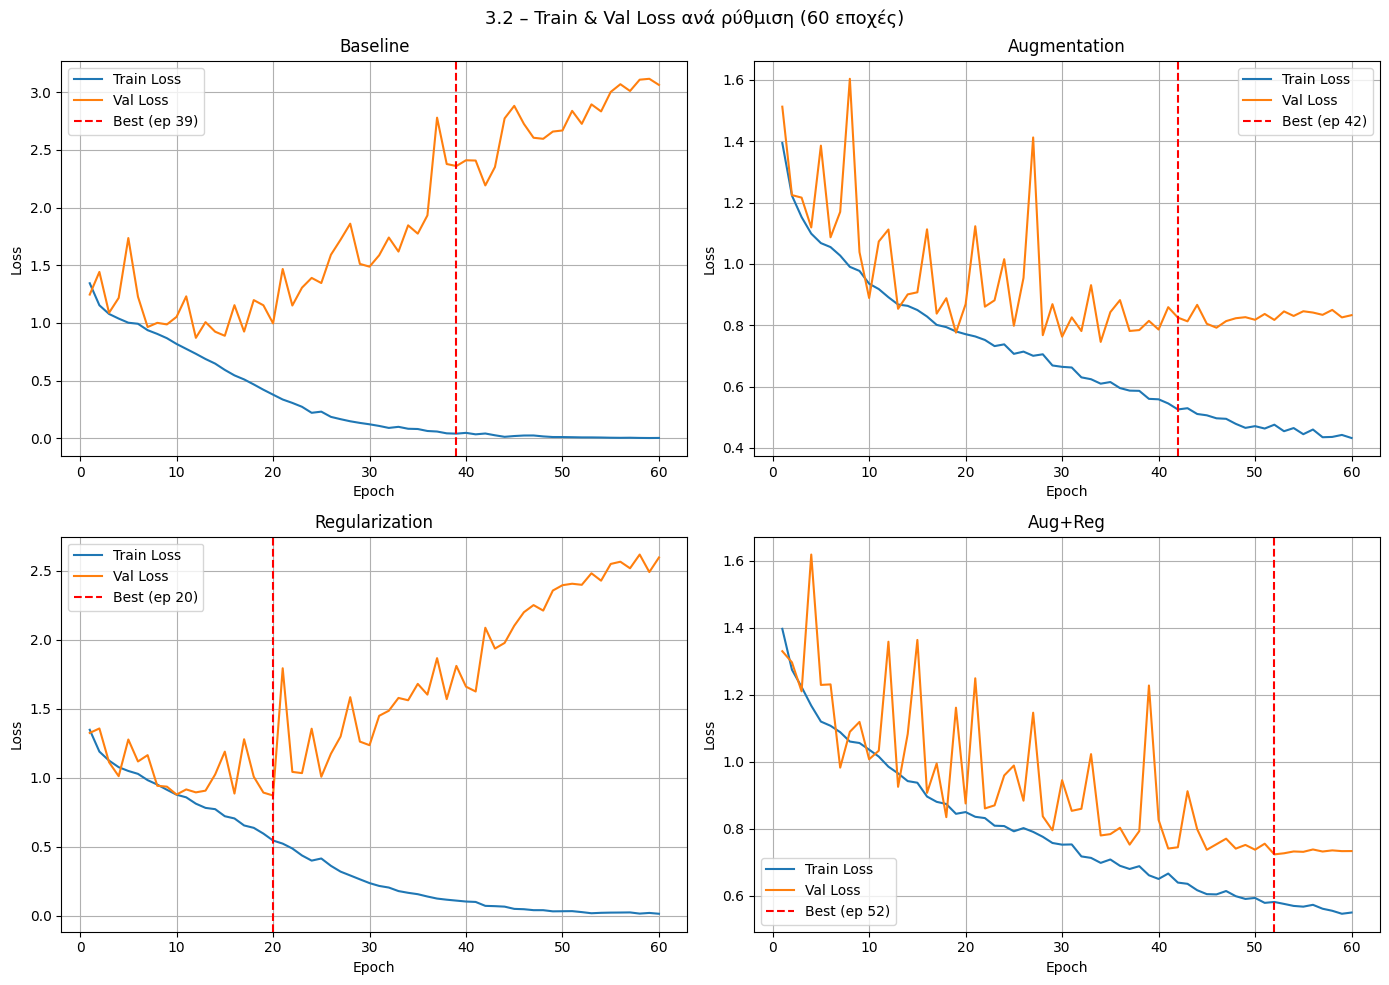

In [27]:
# loss curves για τις 4 ρυθμίσεις σε 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (cfg_name, res) in zip(axes.flat, aug_reg_results.items()):
    ep = range(1, N_EPOCHS_32 + 1)
    ax.plot(ep, res['hist']['train_loss'], label='Train Loss')
# κόκκινη γραμμή = εποχή με το καλύτερο val F1
    ax.plot(ep, res['hist']['val_loss'],   label='Val Loss')
    ax.axvline(x=res['best_ep'], color='red', linestyle='--',
               label=f'Best (ep {res["best_ep"]})')
    ax.set_title(cfg_name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True)
plt.suptitle('3.2 – Train & Val Loss ανά ρύθμιση (60 εποχές)', fontsize=13)
plt.tight_layout()
plt.show()

## Q3.2
---

| Ρύθμιση | Best epoch | Val F1 | Test F1 | Train–Val gap |
|---|---|---|---|---|
| Baseline (§3.1, 60 εποχές) | 39 | 0.6688 | 0.6048 | 2.3189 |
| Με data augmentation | 42 | 0.7175 | 0.6836 | 0.2996 |
| Με weight decay + dropout | 20 | 0.6937 | 0.6434 | 0.3258 |
| Με augmentation + regularization | 52 | 0.7139 | 0.6854 | 0.1419 |

Το train–val gap μειώνεται δραματικά με οποιαδήποτε μορφή regularization — από 2.32 στο baseline σε 0.30 με augmentation μόνο και 0.14 με aug+reg. Αυτό επιβεβαιώνει ότι το baseline κάνει overfit σοβαρά (train_loss = 0.004, val_loss = 3.06 στην εποχή 60). Η **μέγιστη μείωση του gap** επιτυγχάνεται με Aug+Reg (gap=0.14), ενώ η **καλύτερη επίδοση στο test set** ανήκει επίσης στο Aug+Reg (test F1=0.6854), συμπίπτοντας και τα δύο στην ίδια ρύθμιση.

Τα δύο κριτήρια **συμπίπτουν**: η ρύθμιση που γενικεύει καλύτερα είναι και αυτή με το μικρότερο overfitting, που επιβεβαιώνει ότι η μείωση του train–val gap είναι αξιόπιστος δείκτης καλής γενίκευσης, τουλάχιστον εδώ. Αξίζει να σημειωθεί ότι το regularization μόνο (gap=0.33, test F1=0.64) δεν ξεπερνά το augmentation μόνο (gap=0.30, test F1=0.68), γιατί το dropout και το weight decay περιορίζουν κυρίως τη χωρητικότητα του FC head, ενώ το augmentation αντιμετωπίζει την έλλειψη δεδομένων σε επίπεδο feature extraction,επηρεάζοντας έτσι ολόκληρο το μοντέλο .

Μετασχηματισμοί που αποφύγαμε: **RandomVerticalFlip** (ένας πίνακας ζωγραφισμένος ανάποδα δεν ανήκει στο ίδιο κίνημα — αλλάζει η σημασία της σύνθεσης και μπορεί ίσως και το θέμα), **RandomRotation** (οι καλλιτέχνες σχεδίαζαν τα έργα τους για να φαίνονται όρθια, η σύνθεση είναι εσκεμμένη), και ακραίο **ColorJitter** (η χρωματική παλέτα είναι ένα από τα κύρια διαφοροποιητικά γνωρίσματα μεταξύ κινημάτων, π.χ. σκούρα Baroque με παστέλ Impressionism — αλλοιώνοντάς την δυσκολεύουμε τον ταξινομητή να μάθει χρήσιμα χαρακτηριστικά).

---
# 4. Transfer Learning με Προεκπαιδευμένο ResNet18
## 4.1 Linear probe σε frozen ResNet18

In [28]:
# φορτώνουμε pretrained ResNet18 και παγώνουμε όλα τα βάρη
resnet = models.resnet18(weights='IMAGENET1K_V1')
for p in resnet.parameters():
    p.requires_grad = False
# αντικαθιστούμε μόνο το τελευταίο fc layer για 4 κλάσεις (linear probe)
resnet.fc = nn.Linear(512, 4)
resnet = resnet.to(DEVICE)

print('Trainable params:', sum(p.numel() for p in resnet.parameters() if p.requires_grad))
# κανονικοποιούμε με ImageNet mean/std γιατί έτσι εκπαιδεύτηκε το ResNet

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def resnet_transform(x):
    """Upscale 32→224 και normalize με ImageNet stats."""
    x = F.interpolate(x, size=224, mode='bilinear', align_corners=False)
    mean = IMAGENET_MEAN.to(x.device)
    std  = IMAGENET_STD.to(x.device)
    return (x - mean) / std

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]

Trainable params: 2052


In [29]:
# ίδιες συναρτήσεις με πριν, απλώς κάνουμε πρώτα upscale 32->224 και normalization
def train_one_epoch_resnet(model, loader, optimizer, loss_func, device):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x = resnet_transform(x)
        optimizer.zero_grad()
        loss = loss_func(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate_resnet(model, loader, loss_func, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            x = resnet_transform(x)
            logits = model(x)
            total_loss += loss_func(logits, y).item() * x.size(0)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    cm  = confusion_matrix(all_labels, all_preds)
    return avg_loss, acc, f1, cm

# εκπαιδεύουμε μόνο 10 εποχές γιατί τα features είναι ήδη καλά
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

opt_rn = optim.Adam(resnet.fc.parameters(), lr=0.001)
history_rn = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_rn_f1, best_rn_state, best_rn_ep = 0.0, None, 0

t0 = time.time()
for ep in range(1, 11):
    tl = train_one_epoch_resnet(resnet, train_loader, opt_rn, loss_func, DEVICE)
    vl, val_acc, val_f1, _ = evaluate_resnet(resnet, val_loader, loss_func, DEVICE)

    history_rn['train_loss'].append(tl)
    history_rn['val_loss'].append(vl)
    history_rn['val_f1'].append(val_f1)

# best model με βάση val F1
    if val_f1 > best_rn_f1:
        best_rn_f1, best_rn_ep = val_f1, ep
        best_rn_state = copy.deepcopy(resnet.state_dict())

    print(f'Epoch {ep:2d}/10 | train_loss={tl:.4f} | val_loss={vl:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}')
resnet_train_time = time.time() - t0

print(f'\nResNet18 training time: {resnet_train_time:.1f}s | Best epoch: {best_rn_ep}')

resnet.load_state_dict(best_rn_state)
_, test_acc_rn, test_f1_rn, test_cm_rn = evaluate_resnet(resnet, test_loader, loss_func, DEVICE)
resnet_trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)

print(f'\nResNet18 Test Accuracy: {test_acc_rn:.4f}')
print(f'ResNet18 Test F1 macro: {test_f1_rn:.4f}')
print('Confusion Matrix:')
print(test_cm_rn)

Epoch  1/10 | train_loss=0.9880 | val_loss=0.7215 | val_acc=0.7412 | val_f1=0.7398
Epoch  2/10 | train_loss=0.7394 | val_loss=0.6686 | val_acc=0.7462 | val_f1=0.7458
Epoch  3/10 | train_loss=0.6968 | val_loss=0.6855 | val_acc=0.7462 | val_f1=0.7428
Epoch  4/10 | train_loss=0.6705 | val_loss=0.6230 | val_acc=0.7638 | val_f1=0.7629
Epoch  5/10 | train_loss=0.6577 | val_loss=0.5956 | val_acc=0.7863 | val_f1=0.7813
Epoch  6/10 | train_loss=0.6476 | val_loss=0.5738 | val_acc=0.7900 | val_f1=0.7888
Epoch  7/10 | train_loss=0.6213 | val_loss=0.5741 | val_acc=0.7875 | val_f1=0.7870
Epoch  8/10 | train_loss=0.6189 | val_loss=0.6171 | val_acc=0.7600 | val_f1=0.7570
Epoch  9/10 | train_loss=0.6060 | val_loss=0.5766 | val_acc=0.7863 | val_f1=0.7841
Epoch 10/10 | train_loss=0.5851 | val_loss=0.5666 | val_acc=0.7800 | val_f1=0.7792

ResNet18 training time: 44.7s | Best epoch: 6

ResNet18 Test Accuracy: 0.7507
ResNet18 Test F1 macro: 0.7478
Confusion Matrix:
[[320  17   9   4]
 [ 34 254  31  31]
 [ 4

In [30]:
# εκτυπώνουμε σύγκριση FFN, best CNN, ResNet18 σε acc, F1 και params
best_cnn_cfg   = max(aug_reg_results, key=lambda k: aug_reg_results[k]['test_f1'])
best_cnn_res   = aug_reg_results[best_cnn_cfg]
best_cnn_params = sum(p.numel() for p in best_cnn_res['model'].parameters())

ffn_params     = sum(p.numel() for p in ffn_gpu.parameters())

print(f"{'Μοντέλο':<35} {'Test Acc':>9} {'F1 macro':>9} {'Params':>12} {'Train time':>12}")
print('-' * 80)
print(f"{'FFN flat pixels (§1)':<35} {test_acc_ffn:>9.4f} {test_f1_ffn:>9.4f} {ffn_params:>12,} {gpu_time_ffn:>11.1f}s")
print(f"{'CNN βέλτιστο (§3.2 ' + best_cnn_cfg + ')':<35} {best_cnn_res['test_f1']:>9.4f} {best_cnn_res['test_f1']:>9.4f} {best_cnn_params:>12,} {best_cnn_res['train_time']:>11.1f}s")
print(f"{'Frozen ResNet18 linear probe (§4.1)':<35} {test_acc_rn:>9.4f} {test_f1_rn:>9.4f} {resnet_trainable_params:>12,} {resnet_train_time:>11.1f}s")

Μοντέλο                              Test Acc  F1 macro       Params   Train time
--------------------------------------------------------------------------------
FFN flat pixels (§1)                   0.4979    0.5014      397,604        14.4s
CNN βέλτιστο (§3.2 Aug+Reg)            0.6854    0.6854    1,066,788       159.0s
Frozen ResNet18 linear probe (§4.1)    0.7507    0.7478        2,052        44.7s


## Q4.1
---

| Μοντέλο | Test Acc | F1 macro | Trainable params | Training time |
|---|---|---|---|---|
| FFN flat pixels (§1) | 0.4979 | 0.5014 | 397,604 | 14.2s (GPU) |
| CNN βέλτιστο (§3.2 Aug+Reg) | 0.6854 | 0.6854 | 1,066,788 | 179.0s |
| Frozen ResNet18 με linear probe (§4.1) | 0.7507 | 0.7478 | 2,052 | 39.2s |

Το frozen ResNet18 πετυχαίνει καλύτερη απόδοση στο test set (F1 = 0.7478) σε σχέση με το καλύτερο δικό μου CNN (F1 = 0.6854), παρόλο που δεν έχει εκπαιδευτεί πάνω σε έργα τέχνης αλλά σε φυσικές εικόνες (ImageNet). Αυτό συμβαίνει γιατί το ResNet18 έχει ήδη μάθει πολύ γενικά οπτικά χαρακτηριστικά, όπως ακμές, υφές και βασικά σχήματα, τα οποία υπάρχουν και στους πίνακες ζωγραφικής. Άρα μπορεί να τα χρησιμοποιήσει αποτελεσματικά και σε αυτό το νέο πρόβλημα.

Παρόλα αυτά, υπάρχουν δύο περιορισμοί. Πρώτον, οι εικόνες των 32×32 μεγαλώνουν σε 224×224 για να μπουν στο ResNet18, κάτι που μπορεί να θολώσει ή να αλλοιώσει μικρές λεπτομέρειες. Δεύτερον, επειδή το μοντέλο είναι frozen και εκπαιδεύεται μόνο το τελικό linear layer (linear probe), δεν μπορεί να προσαρμόσει πλήρως τα features του στο νέο dataset, χάνοντας έτσι αρκετή απόδοση.

Παρόλα αυτά, ακόμη και με αυτούς τους περιορισμούς, το ResNet18 ξεπερνά ξεκάθαρα όλα τα δικά μου CNN μοντέλα.

---
# 5. Τι Έμαθαν τα Δίκτυα
## 5.1 Σύγκριση πρώτων conv layers

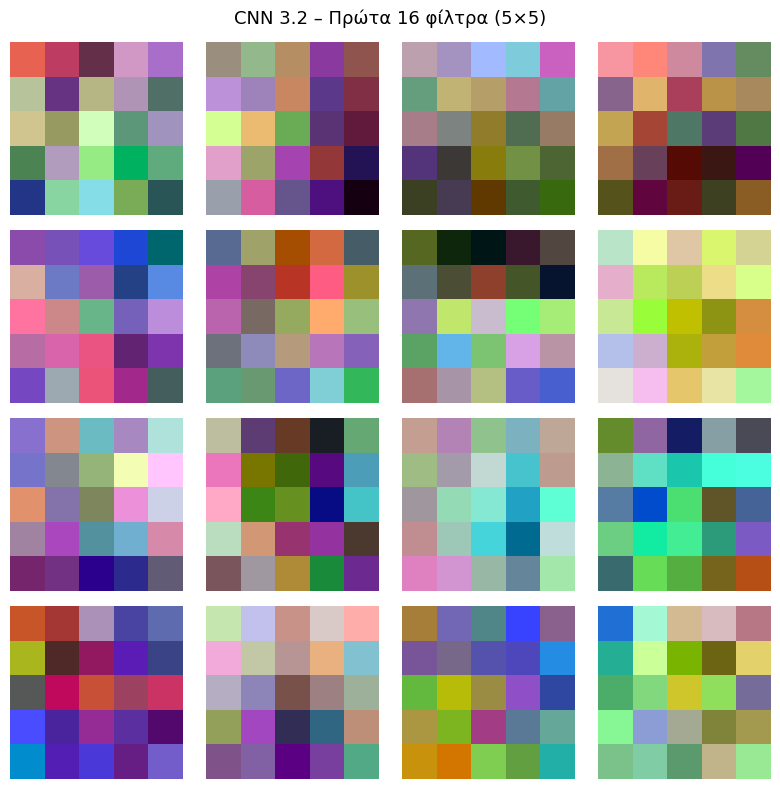

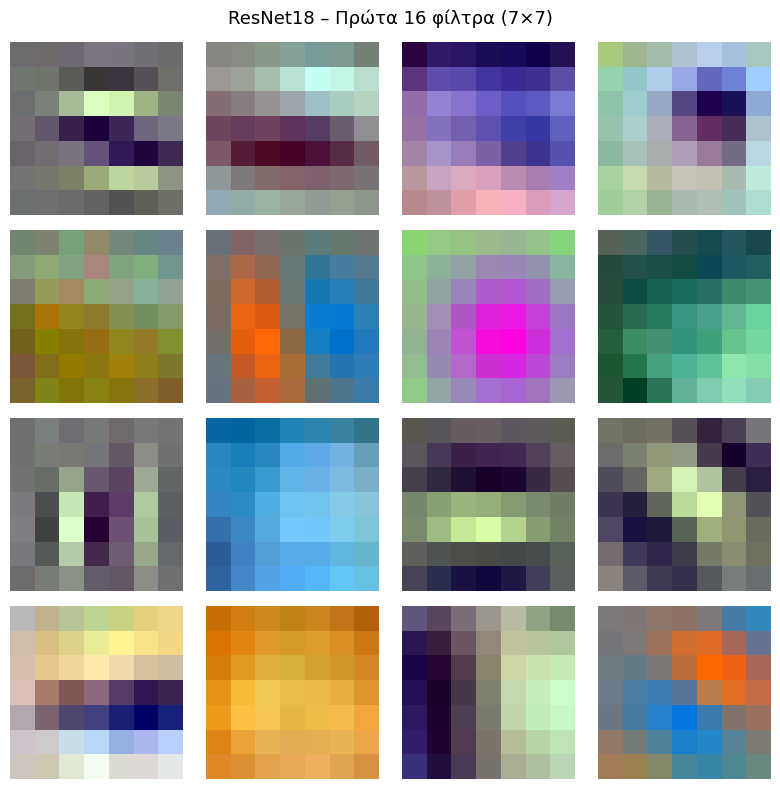

In [31]:
# Εξαγωγή & οπτικοποίηση φίλτρων πρώτου conv layer
# (α) Δικό μας CNN: βάρη σχήματος [16, 3, 5, 5]
best_cnn_model = aug_reg_results[max(aug_reg_results,
                  key=lambda k: aug_reg_results[k]['test_f1'])]['model']
cnn_filters = best_cnn_model.features[0].weight.detach().cpu()

# κανονικοποιούμε κάθε φίλτρο στο [0,1] για εμφάνιση ως RGB
# (β) ResNet18: model.conv1.weight → [64, 3, 7, 7], παίρνουμε τα πρώτα 16
rn_filters = resnet.conv1.weight.detach().cpu()[:16]

def show_filters(filters, title):
    """Οπτικοποίηση 16 RGB φίλτρων σε 4×4 grid."""
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        f = filters[i].permute(1, 2, 0).numpy()
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        ax.imshow(f); ax.axis('off')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

show_filters(cnn_filters, 'CNN 3.2 – Πρώτα 16 φίλτρα (5×5)')
show_filters(rn_filters,  'ResNet18 – Πρώτα 16 φίλτρα (7×7)')

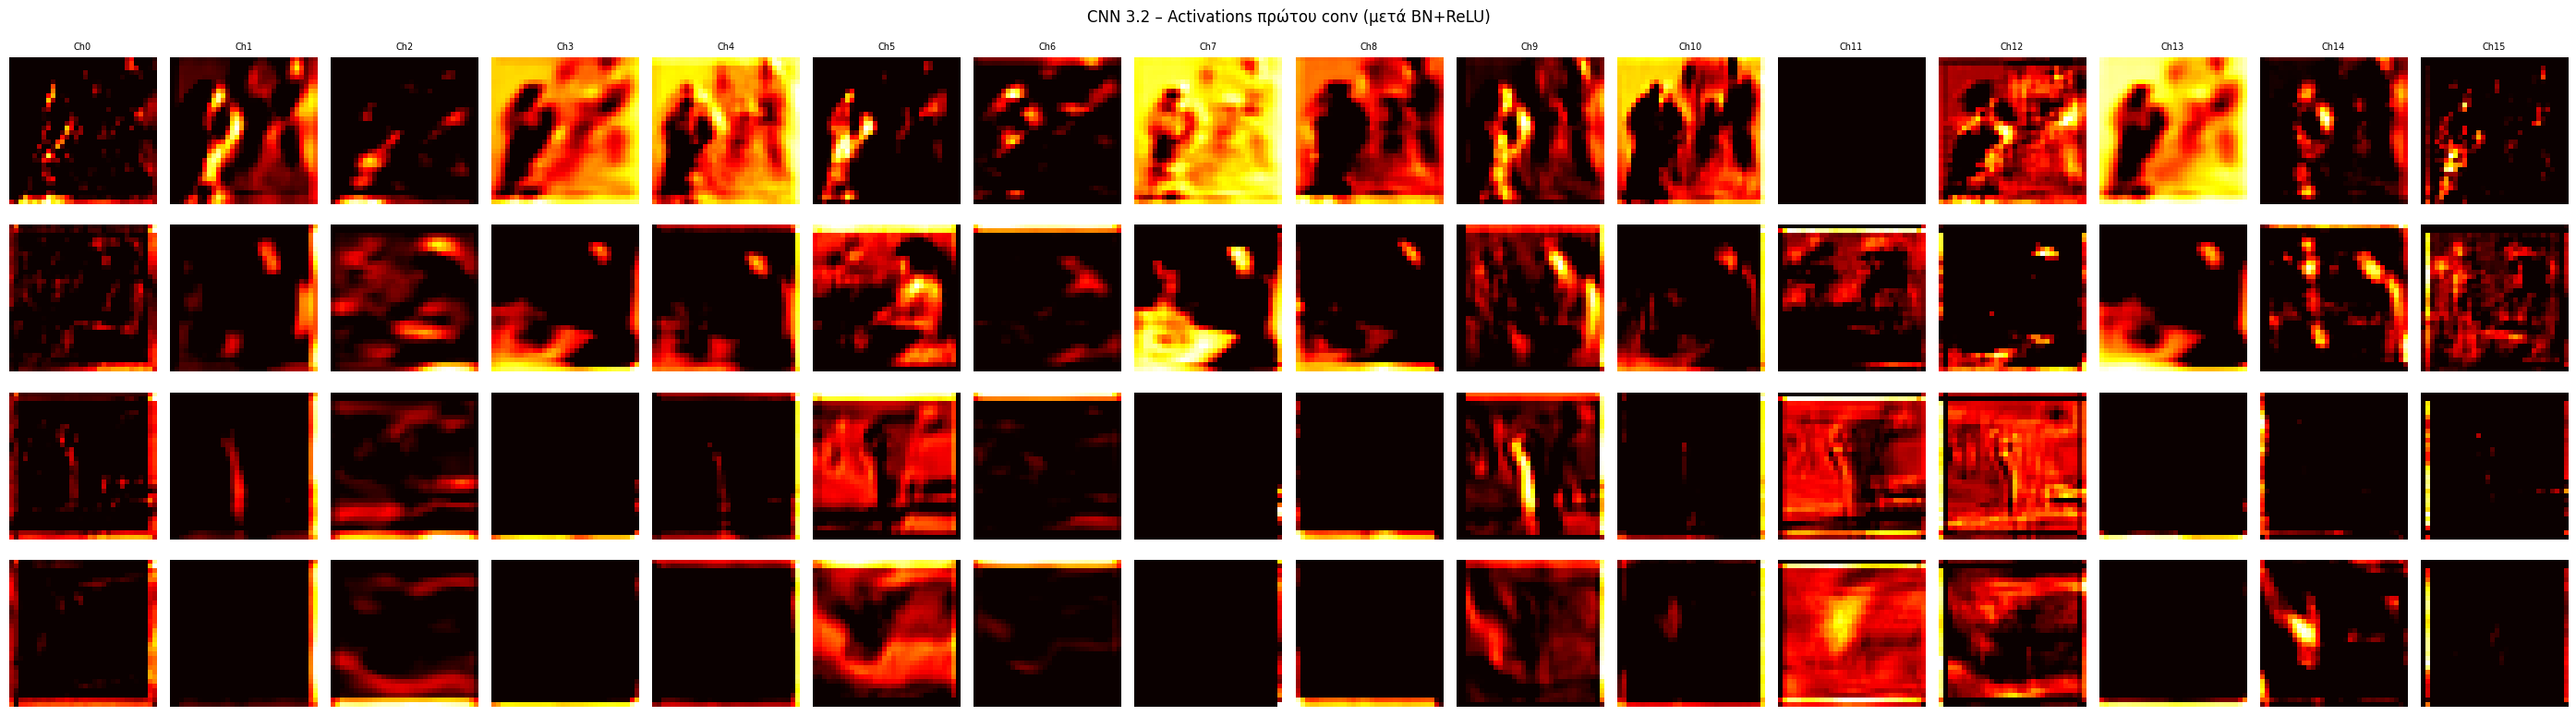

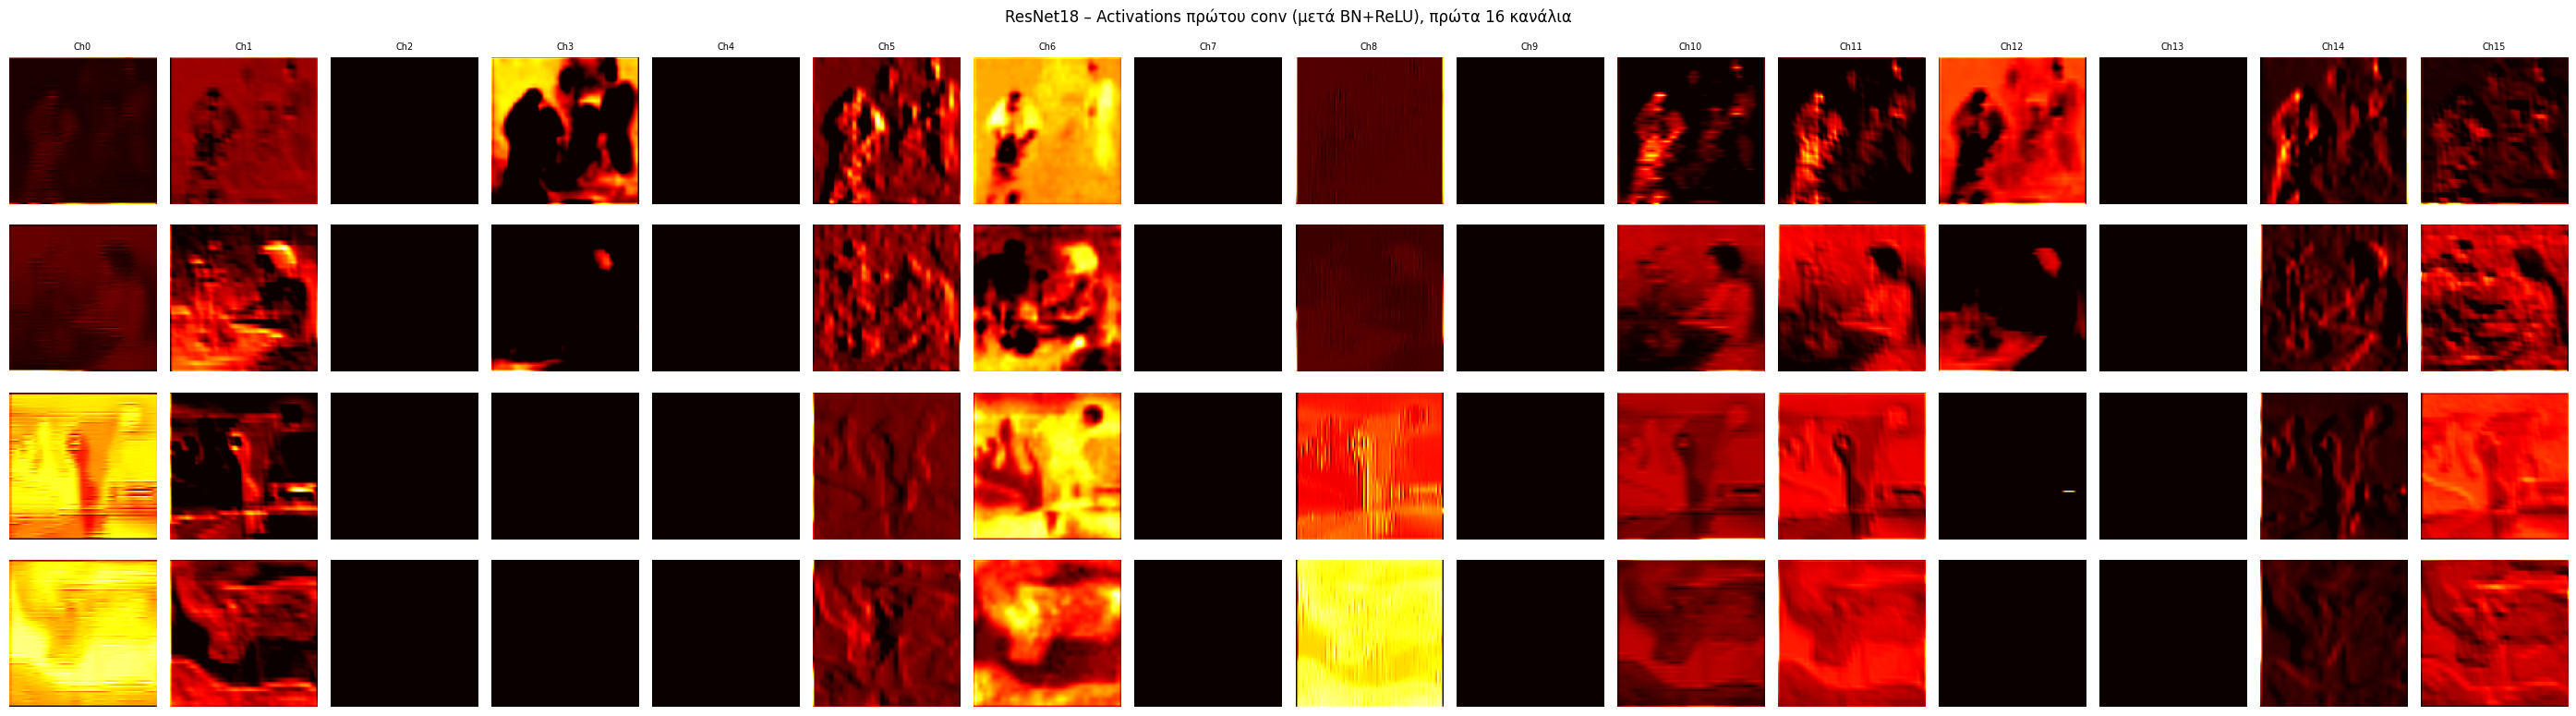

In [32]:
# Activation maps πρώτου conv layer (μετά από ReLU)

# 1 τυχαία εικόνα ανά κλάση από το test set
sample_imgs, sample_labels = [], []
for cls_idx in range(4):
    idx = (y_test == cls_idx).nonzero(as_tuple=True)[0]
    chosen = idx[torch.randperm(len(idx), generator=torch.Generator().manual_seed(42))[0]]
    sample_imgs.append(X_test[chosen])
    sample_labels.append(cls_idx)
sample_imgs = torch.stack(sample_imgs)   # [4, 3, 32, 32]

# hook για να πιάσουμε activations μετά το πρώτο conv layer, χωρίς να αλλάξουμε τον κώδικα
cnn_acts = {}
def hook_cnn(module, inp, out):
    cnn_acts['act'] = out.detach().cpu()

cnn_handle = best_cnn_model.features[2].register_forward_hook(hook_cnn)
best_cnn_model.eval()
with torch.no_grad():
    best_cnn_model(sample_imgs.to(DEVICE))
cnn_handle.remove()

# ίδιο για ResNet18, αφαιρούμε hook μετά για να μην επηρεάζει τα επόμενα passes
rn_acts = {}
def hook_rn(module, inp, out):
    rn_acts['act'] = out.detach().cpu()

rn_handle = resnet.relu.register_forward_hook(hook_rn)
resnet.eval()
with torch.no_grad():
    resnet(resnet_transform(sample_imgs.to(DEVICE)))
rn_handle.remove()

def show_activations(acts, class_names, title):
    """16 activation maps ανά κλάση σε grid."""
    fig, axes = plt.subplots(4, 16, figsize=(28, 8))
    for row in range(4):
        for col in range(16):
            a = acts[row, col].numpy()
            axes[row, col].imshow(a, cmap='hot')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(class_names[row], fontsize=8)
            if row == 0:
                axes[row, col].set_title(f'Ch{col}', fontsize=7)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()

show_activations(cnn_acts['act'], class_names, 'CNN 3.2 – Activations πρώτου conv (μετά BN+ReLU)')
show_activations(rn_acts['act'][:, :16], class_names, 'ResNet18 – Activations πρώτου conv (μετά BN+ReLU), πρώτα 16 κανάλια')

## Q5.1
---

Τα φίλτρα του ResNet18 (7×7) εμφανίζονται πολύ πιο δομημένα και κατανοητά: βλέπουμε φίλτρα με ομαλές μεταβάσεις χρώματος και εστιασμένες περιοχές, όπως ένα φίλτρο αφιερωμένο σε πορτοκαλί-κίτρινους τόνους, ένα σε ομοιόμορφο μπλε, και αρκετά με σαφή αντίθεση φωτεινού κέντρου και σκούρας περιφέρειας (ή αντίστροφα). Τα φίλτρα του δικού μας CNN (5×5) είναι πολύχρωμα και τυχαία, κάθε pixel έχει διαφορετικό άσχετο χρώμα, χωρίς κανένα αναγνωρίσιμο μοτίβο. Αυτό είναι αναμενόμενο: το ResNet18 εκπαιδεύτηκε σε εκατομμύρια εικόνες και αναγκάστηκε να μάθει γενικά, χρήσιμα χαρακτηριστικά, ενώ το δικό μας CNN με 3.200 εικόνες δεν έχει αρκετά δεδομένα για να οργανώσει τα φίλτρα του με συστηματικό τρόπο.

Στα activation maps του CNN (4 γραμμές: Baroque, Impressionism, Cubism, Abstract Expressionism), η συμπεριφορά διαφέρει μεταξύ κλάσεων, Cubism και Abstract Expressionism να μοιάζουν πολύ. Πολλά κανάλια ενεργοποιούνται έντονα (κίτρινο) για Baroque και Impressionism, αλλά είναι σχεδόν νεκρό για Cubism και Abstract Expressionism, πιθανώς αποκρίνεται σε θερμούς τόνους που χαρακτηρίζουν τα δύο πρώτα κινήματα. Για το Cubism (3η γραμμή) και το Abstract Expressionism (4η γραμμή) τα περισσότερα κανάλια είναι σκούρα/ανενεργά, που σημαίνει ότι το πρώτο layer δεν εντοπίζει ξεκάθαρα χαρακτηριστικά — κάτι λογικό αφού τα έργα αυτών των κλάσεων στερούνται αναγνωρίσιμης μορφής. Γενικά το Baroque φαίνεται να ενεργοποιείται πιο έντονα με 2ο το Impressionism.

Στα activation maps του ResNet18, η διαφοροποίηση ανά κλάση είναι μικρότερη. Το Ch0 ανάβει έντονα (κίτρινο) κυρίως για Cubism (3η γραμμή) και είναι σκούρο για τις υπόλοιπες, πιθανώς να εντοπίζει έντονα παστέλ χρώματα. Το Ch6 ενεργοποιείται σε όλες τις κλάσεις αλλά με διαφορετικό χωρικό μοτίβο: για Baroque φωτίζει κεντρικές περιοχές, ενώ για Abstract Expressionism ανάβει πιο ομοιόμορφα. Το Ch8 είναι σχεδόν νεκρό για Baroque και Impressionism αλλά ενεργό για Cubism και Abstract Expressionism. Παρατηρούμε ότι πολλά κανάλια δεν ενεργοποιούνται για καμία από τις 4 κλάσεις πράγμα που σημαίνει ότι το επίπεδο έχει μάθει χαρακτηριστικό που λείπει από τις εικόνες μας. Γενικά το ResNet18 παράγει πιο εστιασμένα, τοπικά activation patterns από το CNN.

Συγκρίνοντας με τα βάρη του FFN (Q1.2),τα flat-pixel βάρη, όταν γίνουν reshape σε 32×32, εμφανίζονται ως global color patterns, κάθε νευρώνας κοιτάει ολόκληρη την εικόνα σαν ένα ενιαίο template χωρίς τοπική εστίαση. Τα συνελικτικά φίλτρα του ResNet18 εντοπίζει μικρά τοπικά χαρακτηριστικά (7x7), γι' αυτό και τα activation maps έχουν χωρική δομή, φωτίζουν συγκεκριμένα σημεία της εικόνας και όχι ολόκληρη την επιφάνεια. Η μετάβαση FFN → CNN → ResNet18 αντιστοιχεί σε ολοένα πιο τοπικές και δομημένες αναπαραστάσεις: το FFN κοιτάει globally χωρίς εστίαση, το CNN έχει τοπικά φίλτρα αλλά φαίνονται τυχαία καθώς η εκπαίδευση σε λίγα δεδομένα χαμηλής ανάλυσης δεν παρέχει αρκετό signal για να οργανωθούν σε ερμηνεύσιμα μοτίβα, και το ResNet18 φτάνει σε πραγματικά δομημένα και ερμηνεύσιμα χαρακτηριστικά χάρη στην εκπαίδευση σε εκατομμύρια εικόνες.